In [1]:
import os
from xspec import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal

Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

<span style='color:green'> Load the data  </span>

In [2]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_15e-1deg/srctoolout_000_SourceProducts_00001_1halfdeg_mask30/"
filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMF=path+"srctoolout_120_RMF_00001.fits"
fileARF=path+"srctoolout_120_ARF_00001.fits"
#
s1 = Spectrum(filespectrum)
s1.multiresponse[0]=fileRMF
s1.multiresponse[0].arf=fileARF
s1.multiresponse[1]=fileRMF # RMF only for src2

# check the data
AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_15e-1deg/srctoolout_000_SourceProducts_00001_1halfdeg_mask30/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.381e+00 +/- 6.222e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 3.568e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_15e-1deg/srctoolout_000_SourceProducts_00001_1halfdeg_mask30/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.381e+00 +/- 6.222e-03
 Assigned to Data Group 1 and P

Error: cannot read response file srctoolout_120_RMF_00001.fits


<span style='color:green'> Ignore some channels  </span>

In [3]:
AllData.ignore("**-0.3,,9.5-**")

    39 channels (1-39) ignored in spectrum #     1
   129 channels (896-1024) ignored in spectrum #     1



Plot command list is now empty


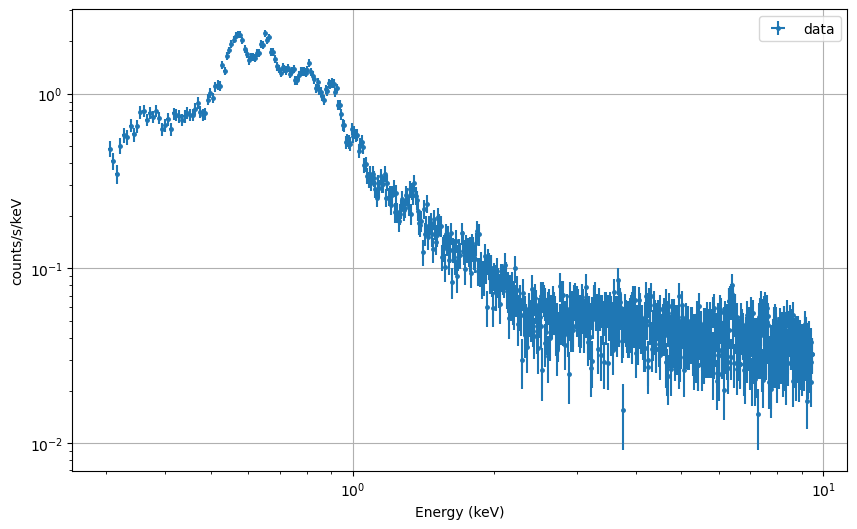

In [4]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

<span style='color:green'> Define the models </span>

In [5]:
#https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/Models.html
Xset.chatter = 1
AllModels.clear()
m_mw = Model("tbabs*(powerlaw+apec)+apec", "mw", 1) 
Xset.restore("/Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/TM1_FWC_v1.0.dat")  # load fwc model from the file
m_fwc = AllModels(1, "fwc")


# More freedom: I allows different parameters to float
# First freeze everything
for _name in m_fwc.componentNames:
    #if (_name != "constant"):
    _comp = m_fwc.__getattribute__(_name)
    for _pname in _comp.parameterNames:
        _par = _comp.__getattribute__(_pname)
        _par.frozen = True
# Now for the gaussians free the normalization and, if you want, also their positions (still keep the min,max range)
for _name in m_fwc.componentNames:
    #print(_name)
    if _name == "gaussian" or (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
    #if (_name == "gaussian"):
        _comp = m_fwc.__getattribute__(_name)
        #print(_comp.parameterNames)
        for _pname in _comp.parameterNames:
            #print(_pname)
            if (_pname == "norm") or (_pname == "LineE"):
                _par = _comp.__getattribute__(_pname)
                _par.frozen = False

# Now free the normalization of the gaussians
for _name in m_fwc.componentNames:
    print(_name)
    if _name == "expfac" or (_name == "bkn2pow") or (_name == "powerlaw") or (_name.startswith("powerlaw") and int(_name.split('_')[-1]) <= 30):
        _comp = m_fwc.__getattribute__(_name)
        print(_comp.parameterNames)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            _par.frozen = False



***Warning: The file sent to Xset.restore(): /Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/TM1_FWC_v1.0.dat
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.


constant
gaussian
gaussian_3
gaussian_4
gaussian_5
gaussian_6
gaussian_7
gaussian_8
gaussian_9
gaussian_10
gaussian_11
gaussian_12
gaussian_13
gaussian_14
gaussian_15
expfac
['Ampl', 'Factor', 'StartE']
bkn2pow
['PhoIndx1', 'BreakE1', 'PhoIndx2', 'BreakE2', 'PhoIndx3', 'norm']
powerlaw
['PhoIndex', 'norm']
powerlaw_19
['PhoIndex', 'norm']


In [6]:
#m_fwc.gaussian.norm.frozen = False
Xset.chatter = 10
AllModels.show()
Xset.chatter = 2

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV  

Milkyway halo has a tempreature about 0.2 keV and metallicity less than 0.1 solar.
Local hot bubble has a temperature about 0.1 keV.
Cosmic X-ray background has a photon index of 1.41 (de Luca & Molendi 2004).

In [6]:
m_mw.TBabs.nH = 4.5e-2
# Try to avoid too large values
#m_mw.TBabs.nH = [0.045, 0.001, 0.0, 0.0, 0.1, 0.1]
m_mw.powerlaw.PhoIndex = 1.46 #1.41 
m_mw.powerlaw.PhoIndex.frozen = True #True
m_mw.apec.kT = 0.2
m_mw.apec.kT.frozen = True #True
m_mw.apec.Abundanc = 1.0
m_mw.apec_4.kT = 0.1
m_mw.apec_4.kT.frozen = True #True
m_mw.apec_4.Abundanc = 1.0

In [7]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 2

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV  

In [8]:
#Xset.abund = "aspl"  # Reference abundance table Asplund+09
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=1000
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

m_mw.apec.kT.frozen = False
m_mw.powerlaw.PhoIndex.frozen = False
m_mw.apec_4.kT.frozen = False
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  1224.631823201956  testStatistics  1336.1424915055102  dof  811  nVarPars  45
Test Statistics  956.4266876296065  testStatistics  1051.481317014112  dof  808  nVarPars  48


In [9]:
Xset.chatter=10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV      9.70635      +/-  4.44031E-02  
   3    2   gaussian   Sigma      keV      1.00000E-04  frozen
   4    2   gaussian   norm                0.122755     +/-  0.565780     
   5    3   gaussian   LineE      keV      9.10159      +/-  6.82760E+14  
   6    3   gaussian   Sigma      keV      1.00000E-04  frozen
   7    3   gaussian   norm                1.11967E-19  +/-  -1.00000     
   8    4   gaussian   LineE      keV      8.27331      +/-  0.162414     
   9    4   gaussian   Sigma      keV      1.00000

Plot command list is now empty


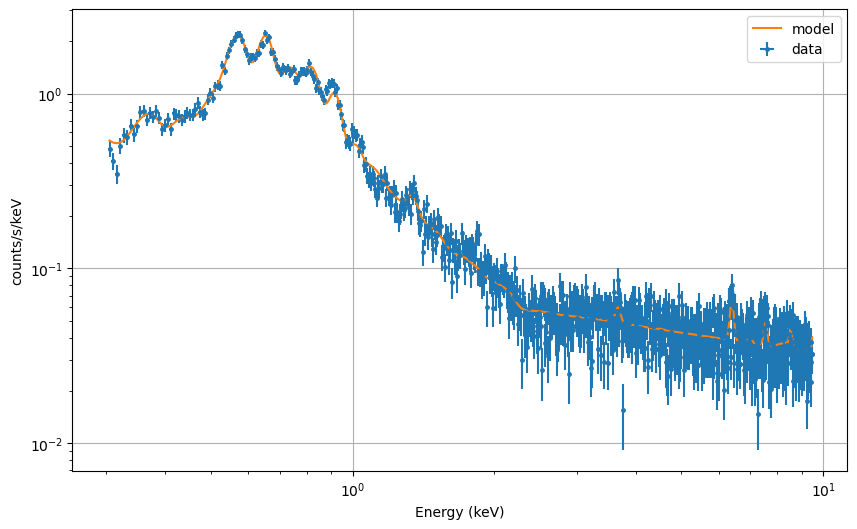

In [ ]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')<3
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [11]:
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)
print("Powel law is ",m_mw.powerlaw.norm.values)
#DeltaOmega = 2*np.pi*(1-np.cos(0.5*np.pi/180.))
#DeltaOmega_deg2 = DeltaOmega*(180/np.pi)**2.
regarea_src_deg2 = fits.getval("/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_5e-1deg/srctoolout_120_SourceSpec_00001.fits", 
                          "regarea", ext=1)
print("DeltaOmega deg2 ",regarea_src_deg2)
print("Powel law norm at 1 keV [ph/cm2/s/keV/arcmin2] ",m_mw.powerlaw.norm.values[0]/(regarea_src_deg2*3600.))
#https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/node134.html
print("APEC MWH norm at 1 keV [cm-5/arcmin2] ",m_mw.apec.norm.values[0]/(regarea_src_deg2*3600.))
print("APEC LHB norm at 1 keV [cm-5/arcmin2] ",m_mw.apec_4.norm.values[0]/(regarea_src_deg2*3600.))
print("TBabs norm is [1e22 atoms cm-2] ",m_mw.TBabs.nH.values[0])
# These number can be compared with Table3 of 2311.07488

Test Statistics  956.4266876296065  testStatistics  1051.481317014112  dof  808  nVarPars  48
Powel law is  [0.04160570891953431, 0.00041605708919534306, 0.0, 0.0, 1e+20, 1e+24]
DeltaOmega deg2  0.5121975274
Powel law norm at 1 keV [ph/cm2/s/keV/arcmin2]  2.2563836700273197e-05
APEC MWH norm at 1 keV [cm-5/arcmin2]  0.00012828839379023732
APEC LHB norm at 1 keV [cm-5/arcmin2]  3.411257662587972e-05
TBabs norm is [1e22 atoms cm-2]  0.24455985709337927


In [59]:
#Powel law is  [0.006893112786186842, 6.893112786186843e-05, 0.0, 0.0, 1e+20, 1e+24]
#DeltaOmega deg2  0.5121975274
#Powel law norm at 1 keV [ph/cm2/s/keV/arcmin2]  3.7383108064542505e-06
#APEC MWH norm at 1 keV [cm-5/arcmin2]  7.064733634349558e-05
#APEC LHB norm at 1 keV [cm-5/arcmin2]  9.722012306566567e-06

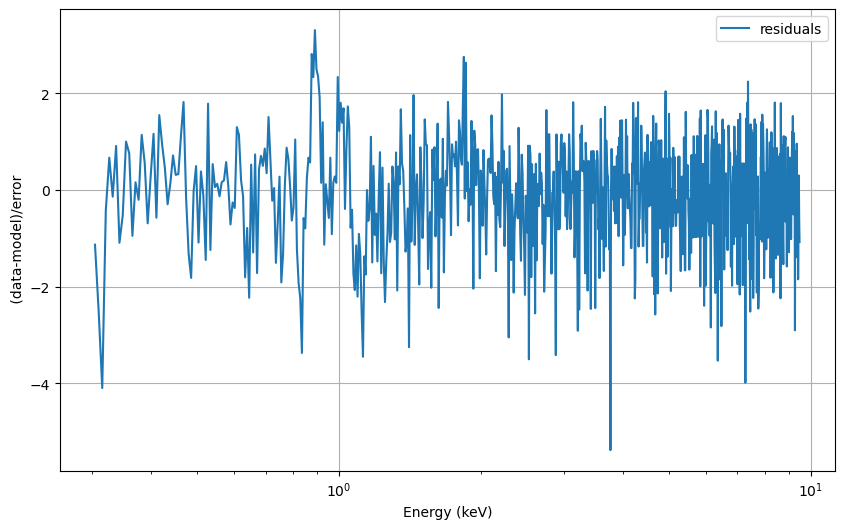

In [12]:
ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [13]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                  956.43     using 856 bins.

Test statistic : Chi-Squared                 1051.48     using 856 bins.
 Null hypothesis probability of 1.40e-08 with 808 degrees of freedom


In [14]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())
nAddComps = int(Plot.nAddComps())
print("nAddComps ",Plot.nAddComps())
modelcomp = np.zeros((nAddComps, len(energies)))
modelcomptot = np.zeros(len(energies))
for i in range(nAddComps):
    #print(i)
    modelcomp[i] = np.asarray(Plot.addComp(i+1))
    modelcomptot = modelcomptot + modelcomp[i]

Plot command list is now empty
nAddComps  20


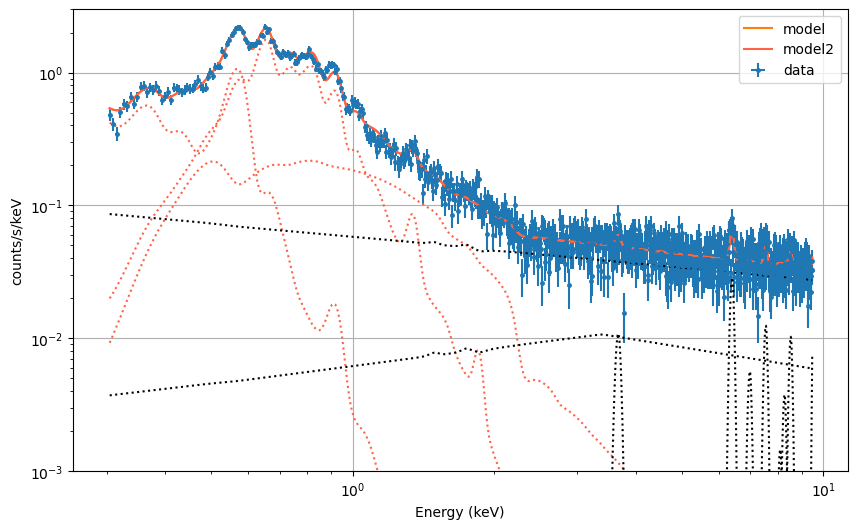

In [16]:
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
ax.plot(energies, modelcomptot,label='model2',linestyle='-', marker='',color='tomato')
for i in range(0,3):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='tomato')
for i in range(3,nAddComps):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')
#DM
#ax.plot(energies, modelcomp[0][:],label='',linestyle=':', marker='',color='green')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((0.001,3.0))
ax.grid()
ax.legend()